# 16. Model Improvements and Optimization

## Objective
This notebook improves the Step-15 baseline using leakage-safe time-series procedures:

1. Threshold Optimization
2. Feature Pruning
3. Probability Calibration
4. Regime-Aware Modeling
5. Ensemble Modeling

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import json
import logging
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp('2023-04-18')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-30')
SEQUENCE_WINDOW = 20

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

logger = logging.getLogger('model_opt')
if not logger.handlers:
    _handler = logging.StreamHandler()
    _handler.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(_handler)
logger.setLevel(logging.INFO)
logger.info('Using device: %s', DEVICE)

[INFO] Using device: cpu


## 1) Load Data and Artifacts

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Could not resolve project root containing ml_pipeline and CLAUDE.md.')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'dataset': base / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
        'feature_importance': base / 'models' / 'baseline_feature_importance.csv',
        'baseline_metrics': base / 'models' / 'baseline_metrics_summary.json',
        'dl_metrics': base / 'models' / 'dl_metrics_summary.json',
        'rf_model': base / 'models' / 'rf_baseline.pkl',
        'xgb_model': base / 'models' / 'xgb_baseline.pkl',
        'lstm_model': base / 'models' / 'lstm_model.pt',
        'transformer_model': base / 'models' / 'transformer_model.pt',
        'threshold_out': base / 'models' / 'optimized_threshold.json',
        'calibrator_out': base / 'models' / 'calibrated_model.pkl',
        'ensemble_out': base / 'models' / 'ensemble_config.json',
        'metrics_out': base / 'models' / 'improved_metrics.json',
    }


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)

for k in ['dataset', 'feature_importance', 'baseline_metrics', 'dl_metrics', 'rf_model', 'xgb_model', 'lstm_model', 'transformer_model']:
    assert PATHS[k].exists(), f'Missing required artifact: {PATHS[k]}'

df = pd.read_parquet(PATHS['dataset']).copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

feature_importance_df = pd.read_csv(PATHS['feature_importance'])
baseline_metrics = json.loads(PATHS['baseline_metrics'].read_text(encoding='utf-8'))
dl_metrics = json.loads(PATHS['dl_metrics'].read_text(encoding='utf-8'))

with open(PATHS['rf_model'], 'rb') as f:
    rf_model = pickle.load(f)
with open(PATHS['xgb_model'], 'rb') as f:
    xgb_model = pickle.load(f)

assert {'Date', 'Ticker', 'target', 'volatility_regime_label'}.issubset(df.columns)
assert df['Date'].min() >= pd.Timestamp('2023-01-01')
assert df['Date'].max() <= pd.Timestamp('2026-01-01')

logger.info('Dataset shape: %s', df.shape)
display(df[['Date', 'Ticker', 'target', 'volatility_regime_label']].head())

[INFO] Dataset shape: (63541, 168)


,Date,Ticker,target,volatility_regime_label
0,2023-04-18,ABB,0,MEDIUM
1,2023-04-19,ABB,0,MEDIUM
2,2023-04-20,ABB,0,MEDIUM
3,2023-04-21,ABB,1,MEDIUM
4,2023-04-24,ABB,1,LOW


## 2) Build Step-15 Consistent Predictions (No Leakage, No Shuffle)

Step-15 uses fixed date ranges and sequence-window alignment. We reproduce those exact splits and prediction rows for all downstream optimization.

In [3]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return self.head(self.dropout(out[:, -1, :])).squeeze(-1)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, input_size: int, d_model: int = 64, n_heads: int = 4, num_layers: int = 2, dropout: float = 0.2, max_len: int = 20):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=d_model * 4,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        return self.head(self.dropout(h[:, -1, :])).squeeze(-1)


def select_features(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    drop_cols = ['Date', 'Ticker', 'target', 'volatility_regime_label', 'vol_cluster_regime_name']
    feature_cols = [c for c in data.columns if c not in drop_cols]
    X = data[feature_cols].copy()
    y = data['target'].astype(int).copy()
    assert X.select_dtypes(exclude=[np.number]).empty, 'Non-numeric feature columns found.'
    assert X.isna().sum().sum() == 0, 'NaNs found in model features.'
    return X, y, feature_cols


def split_data(data: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    train_mask = (data['Date'] >= TRAIN_START) & (data['Date'] <= TRAIN_END)
    test_mask = (data['Date'] >= TEST_START) & (data['Date'] <= TEST_END)

    X_train, X_test = X.loc[train_mask].copy(), X.loc[test_mask].copy()
    y_train, y_test = y.loc[train_mask].copy(), y.loc[test_mask].copy()
    df_train, df_test = data.loc[train_mask].copy(), data.loc[test_mask].copy()

    assert df_train['Date'].max() < df_test['Date'].min(), 'Temporal overlap detected.'
    return X_train, X_test, y_train, y_test, df_train, df_test


def scale_features_train_only(X_train: pd.DataFrame, X_test: pd.DataFrame):
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled


def create_sequences_with_meta(df_part: pd.DataFrame, X_scaled_part: pd.DataFrame, y_part: pd.Series, feature_cols: List[str], window: int = 20):
    seq_X, seq_y, meta_rows = [], [], []
    tmp = df_part[['Ticker', 'Date', 'volatility_regime_label']].copy()
    tmp[feature_cols] = X_scaled_part[feature_cols]
    tmp['target'] = y_part.values
    tmp = tmp.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    for ticker, grp in tmp.groupby('Ticker', sort=False):
        vals = grp[feature_cols].to_numpy(dtype=np.float32)
        lbls = grp['target'].to_numpy(dtype=np.int64)
        dates = grp['Date'].to_numpy()
        regimes = grp['volatility_regime_label'].astype(str).to_numpy()
        if len(grp) <= window:
            continue
        for i in range(window, len(grp)):
            seq_X.append(vals[i - window:i])
            seq_y.append(lbls[i])
            meta_rows.append({'Ticker': ticker, 'Date': pd.Timestamp(dates[i]), 'Regime': regimes[i], 'target': int(lbls[i])})

    return np.asarray(seq_X), np.asarray(seq_y), pd.DataFrame(meta_rows)


def predict_torch_binary(model: nn.Module, X_np: np.ndarray, batch_size: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    prob = np.concatenate(probs)
    pred = (prob >= 0.5).astype(int)
    return pred, prob


X_all, y_all, feature_cols = select_features(df)
X_train, X_test, y_train, y_test, df_train, df_test = split_data(df, X_all, y_all)
X_train_scaled, X_test_scaled = scale_features_train_only(X_train, X_test)

train_base = df_train[['Date', 'Ticker', 'volatility_regime_label']].copy()
train_base['target'] = y_train.values
train_base = train_base.rename(columns={'volatility_regime_label': 'Regime'})
test_base = df_test[['Date', 'Ticker', 'volatility_regime_label']].copy()
test_base['target'] = y_test.values
test_base = test_base.rename(columns={'volatility_regime_label': 'Regime'})

train_base['RandomForest_pred'] = rf_model.predict(X_train)
train_base['RandomForest_prob'] = rf_model.predict_proba(X_train)[:, 1]
train_base['XGBoost_pred'] = xgb_model.predict(X_train)
train_base['XGBoost_prob'] = xgb_model.predict_proba(X_train)[:, 1]

test_base['RandomForest_pred'] = rf_model.predict(X_test)
test_base['RandomForest_prob'] = rf_model.predict_proba(X_test)[:, 1]
test_base['XGBoost_pred'] = xgb_model.predict(X_test)
test_base['XGBoost_prob'] = xgb_model.predict_proba(X_test)[:, 1]

X_seq_train, y_seq_train, seq_meta_train = create_sequences_with_meta(df_train, X_train_scaled, y_train, feature_cols, window=SEQUENCE_WINDOW)
X_seq_test, y_seq_test, seq_meta_test = create_sequences_with_meta(df_test, X_test_scaled, y_test, feature_cols, window=SEQUENCE_WINDOW)

lstm_model = LSTMClassifier(input_size=len(feature_cols)).to(DEVICE)
transformer_model = TransformerClassifier(input_size=len(feature_cols), max_len=SEQUENCE_WINDOW).to(DEVICE)
lstm_model.load_state_dict(torch.load(PATHS['lstm_model'], map_location=DEVICE))
transformer_model.load_state_dict(torch.load(PATHS['transformer_model'], map_location=DEVICE))

lstm_train_pred, lstm_train_prob = predict_torch_binary(lstm_model, X_seq_train)
trf_train_pred, trf_train_prob = predict_torch_binary(transformer_model, X_seq_train)
lstm_test_pred, lstm_test_prob = predict_torch_binary(lstm_model, X_seq_test)
trf_test_pred, trf_test_prob = predict_torch_binary(transformer_model, X_seq_test)

seq_train = seq_meta_train.copy()
seq_train['LSTM_pred'] = lstm_train_pred
seq_train['LSTM_prob'] = lstm_train_prob
seq_train['Transformer_pred'] = trf_train_pred
seq_train['Transformer_prob'] = trf_train_prob

seq_test = seq_meta_test.copy()
seq_test['LSTM_pred'] = lstm_test_pred
seq_test['LSTM_prob'] = lstm_test_prob
seq_test['Transformer_pred'] = trf_test_pred
seq_test['Transformer_prob'] = trf_test_prob

aligned_train = seq_train.merge(
    train_base[['Date', 'Ticker', 'RandomForest_pred', 'RandomForest_prob', 'XGBoost_pred', 'XGBoost_prob']],
    on=['Date', 'Ticker'],
    how='left',
)
aligned_test = seq_test.merge(
    test_base[['Date', 'Ticker', 'RandomForest_pred', 'RandomForest_prob', 'XGBoost_pred', 'XGBoost_prob']],
    on=['Date', 'Ticker'],
    how='left',
)

assert aligned_train[['RandomForest_prob', 'XGBoost_prob']].isna().sum().sum() == 0
assert aligned_test[['RandomForest_prob', 'XGBoost_prob']].isna().sum().sum() == 0
assert aligned_train['Date'].max() < aligned_test['Date'].min(), 'Temporal overlap in aligned predictions.'

logger.info('Aligned train rows: %s | Aligned test rows: %s', f'{len(aligned_train):,}', f'{len(aligned_test):,}')
display(aligned_test.head())

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16856\9202137.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16856\9202137.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16856\9202137.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

,Ticker,Date,Regime,target,LSTM_pred,LSTM_prob,Transformer_pred,Transformer_prob,RandomForest_pred,RandomForest_prob,XGBoost_pred,XGBoost_prob
0,ABB,2025-01-29,HIGH,0,0,0.496905,0,0.494498,1,0.519582,1,0.529273
1,ABB,2025-01-30,HIGH,1,1,0.576439,1,0.502987,1,0.620482,1,0.691457
2,ABB,2025-01-31,HIGH,0,1,0.580866,0,0.492936,0,0.448544,0,0.351550
3,ABB,2025-02-01,HIGH,0,1,0.552348,1,0.506073,1,0.509517,1,0.658980
4,ABB,2025-02-03,HIGH,1,1,0.520580,0,0.496291,1,0.506105,1,0.591766


## 3) Feature Pruning

In [4]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    return {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
        'ROC_AUC': float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
    }


def build_validation_mask(df_split: pd.DataFrame, val_fraction: float = 0.2):
    dates = np.sort(df_split['Date'].drop_duplicates().to_numpy())
    idx = max(1, int(len(dates) * (1 - val_fraction)))
    idx = min(idx, len(dates) - 1)
    val_start = pd.Timestamp(dates[idx])
    val_mask = df_split['Date'] >= val_start
    train_mask = ~val_mask
    assert df_split.loc[train_mask, 'Date'].max() < df_split.loc[val_mask, 'Date'].min()
    return train_mask, val_mask, val_start


def prune_features(
    feature_importance: pd.DataFrame,
    X_train_full: pd.DataFrame,
    y_train_full: pd.Series,
    X_test_full: pd.DataFrame,
    y_test_aligned: np.ndarray,
    df_train_full: pd.DataFrame,
    df_test_full: pd.DataFrame,
    aligned_test_local: pd.DataFrame,
    xgb_base,
    top_n: int = 100,
):
    assert 80 <= top_n <= 100, 'top_n must be in [80, 100].'
    fi_xgb = feature_importance[feature_importance['model'].str.upper() == 'XGBOOST'].sort_values('importance', ascending=False)
    top_features = [f for f in fi_xgb['feature'] if f in X_train_full.columns][:top_n]
    assert len(top_features) >= 80, 'Insufficient ranked features available in dataset.'

    tr_mask, val_mask, val_start = build_validation_mask(df_train_full)
    X_tr = X_train_full.loc[tr_mask, top_features]
    y_tr = y_train_full.loc[tr_mask]
    X_val = X_train_full.loc[val_mask, top_features]
    y_val = y_train_full.loc[val_mask]

    model = clone(xgb_base)
    model.fit(X_tr, y_tr)

    val_prob = model.predict_proba(X_val)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    val_metrics = compute_metrics(y_val.to_numpy(), val_pred, val_prob)

    test_probs_all = model.predict_proba(X_test_full[top_features])[:, 1]
    pruned_full = df_test_full[['Date', 'Ticker']].copy()
    pruned_full['PrunedXGB_prob'] = test_probs_all
    pruned_full['PrunedXGB_pred'] = (pruned_full['PrunedXGB_prob'] >= 0.5).astype(int)

    aligned_pruned = aligned_test_local[['Date', 'Ticker']].merge(pruned_full, on=['Date', 'Ticker'], how='left')
    assert aligned_pruned['PrunedXGB_prob'].isna().sum() == 0, 'Pruned prediction alignment failed.'
    test_metrics = compute_metrics(y_test_aligned, aligned_pruned['PrunedXGB_pred'].to_numpy(), aligned_pruned['PrunedXGB_prob'].to_numpy())

    return {
        'model': model,
        'top_features': top_features,
        'val_start': str(val_start.date()),
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
    }


prune_result = prune_features(
    feature_importance=feature_importance_df,
    X_train_full=X_train,
    y_train_full=y_train,
    X_test_full=X_test,
    y_test_aligned=aligned_test['target'].to_numpy(),
    df_train_full=df_train,
    df_test_full=df_test,
    aligned_test_local=aligned_test,
    xgb_base=xgb_model,
    top_n=100,
)

X_pruned = X_test[prune_result['top_features']].copy()
logger.info('Pruned features kept: %d', len(prune_result['top_features']))
display(pd.DataFrame([prune_result['val_metrics'], prune_result['test_metrics']], index=['PrunedXGB_Val', 'PrunedXGB_Test']).round(4))

[INFO] Pruned features kept: 100


,Accuracy,Precision,Recall,F1,ROC_AUC
PrunedXGB_Val,0.4851,0.4691,0.6350,0.5396,0.4944
PrunedXGB_Test,0.5130,0.5117,0.6282,0.5640,0.5188


## 4) Threshold Optimization

[INFO] Validation start: 2024-09-04 | optimal_threshold: 0.41


,threshold,Precision,Recall,F1
11,0.41,0.4730,0.9989,0.6420
8,0.38,0.4727,1.0000,0.6420
9,0.39,0.4728,0.9997,0.6420
10,0.40,0.4729,0.9995,0.6420
0,0.30,0.4727,1.0000,0.6419
4,0.34,0.4727,1.0000,0.6419
1,0.31,0.4727,1.0000,0.6419
3,0.33,0.4727,1.0000,0.6419
2,0.32,0.4727,1.0000,0.6419
7,0.37,0.4727,1.0000,0.6419


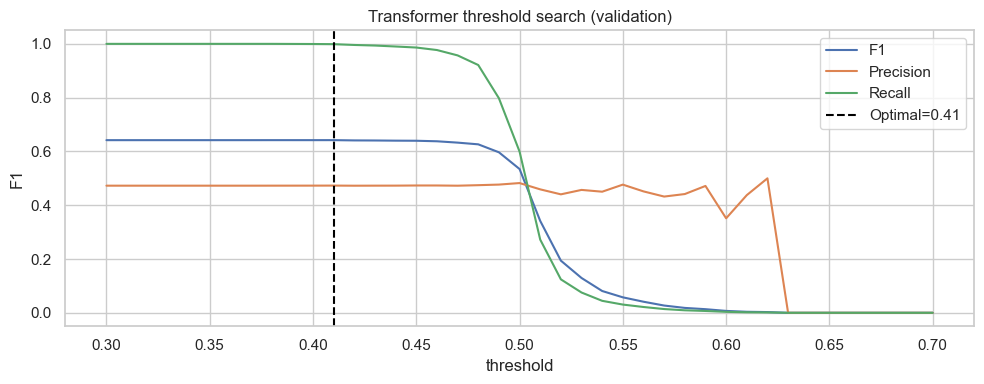

In [5]:
def optimize_threshold(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray | None = None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.30, 0.701, 0.01), 2)
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        rows.append({
            'threshold': float(t),
            'Precision': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred, zero_division=0),
            'F1': f1_score(y_true, pred, zero_division=0),
        })
    curve = pd.DataFrame(rows)
    best = curve.sort_values(['F1', 'Precision', 'threshold'], ascending=[False, False, True]).iloc[0]
    return float(best['threshold']), curve


tr_mask, val_mask, val_start = build_validation_mask(aligned_train)
val_frame = aligned_train.loc[val_mask].copy()
test_frame = aligned_test.copy()

optimal_threshold, threshold_table = optimize_threshold(
    y_true=val_frame['target'].to_numpy(),
    y_prob=val_frame['Transformer_prob'].to_numpy(),
)

test_frame['final_pred_thresholded'] = (test_frame['Transformer_prob'] >= optimal_threshold).astype(int)
logger.info('Validation start: %s | optimal_threshold: %.2f', val_start.date(), optimal_threshold)

display(threshold_table.sort_values('F1', ascending=False).head(10).round(4))
plt.figure(figsize=(10, 4))
sns.lineplot(data=threshold_table, x='threshold', y='F1', label='F1')
sns.lineplot(data=threshold_table, x='threshold', y='Precision', label='Precision')
sns.lineplot(data=threshold_table, x='threshold', y='Recall', label='Recall')
plt.axvline(optimal_threshold, linestyle='--', color='black', label=f'Optimal={optimal_threshold:.2f}')
plt.title('Transformer threshold search (validation)')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Probability Calibration (Platt Scaling)

In [6]:
def calibrate_model(val_prob: np.ndarray, val_y: np.ndarray, test_prob: np.ndarray):
    calibrator = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    calibrator.fit(val_prob.reshape(-1, 1), val_y)
    val_cal = calibrator.predict_proba(val_prob.reshape(-1, 1))[:, 1]
    test_cal = calibrator.predict_proba(test_prob.reshape(-1, 1))[:, 1]
    return calibrator, val_cal, test_cal


calibrator, val_prob_cal, test_prob_cal = calibrate_model(
    val_prob=val_frame['Transformer_prob'].to_numpy(),
    val_y=val_frame['target'].to_numpy(),
    test_prob=test_frame['Transformer_prob'].to_numpy(),
)

test_frame['Transformer_prob_calibrated'] = test_prob_cal
test_frame['Transformer_pred_calibrated'] = (test_frame['Transformer_prob_calibrated'] >= 0.5).astype(int)

val_before = compute_metrics(
    val_frame['target'].to_numpy(),
    (val_frame['Transformer_prob'].to_numpy() >= 0.5).astype(int),
    val_frame['Transformer_prob'].to_numpy(),
)
val_after = compute_metrics(
    val_frame['target'].to_numpy(),
    (val_prob_cal >= 0.5).astype(int),
    val_prob_cal,
)

display(pd.DataFrame([val_before, val_after], index=['BeforeCalibration_Val', 'AfterCalibration_Val']).round(4))

,Accuracy,Precision,Recall,F1,ROC_AUC
BeforeCalibration_Val,0.5067,0.4824,0.5995,0.5346,0.5015
AfterCalibration_Val,0.5273,0.0000,0.0000,0.0000,0.4985


## 6) Regime-Aware Modeling

In [7]:
def build_regime_model(regimes: pd.Series, transformer_prob: np.ndarray, xgb_prob: np.ndarray, threshold: float):
    r = regimes.astype(str).str.upper()
    regime_prob = np.where(r == 'LOW', xgb_prob, transformer_prob)
    regime_pred = (regime_prob >= threshold).astype(int)
    return regime_pred, regime_prob


test_frame['regime_based_prediction'], test_frame['regime_based_probability'] = build_regime_model(
    regimes=test_frame['Regime'],
    transformer_prob=test_frame['Transformer_prob'].to_numpy(),
    xgb_prob=test_frame['XGBoost_prob'].to_numpy(),
    threshold=optimal_threshold,
)

display(test_frame[['Date', 'Ticker', 'Regime', 'target', 'regime_based_probability', 'regime_based_prediction']].head())

,Date,Ticker,Regime,target,regime_based_probability,regime_based_prediction
0,2025-01-29,ABB,HIGH,0,0.494498,1
1,2025-01-30,ABB,HIGH,1,0.502987,1
2,2025-01-31,ABB,HIGH,0,0.492936,1
3,2025-02-01,ABB,HIGH,0,0.506073,1
4,2025-02-03,ABB,HIGH,1,0.496291,1


## 7) Ensemble Model

In [8]:
def ensemble_predictions(transformer_prob: np.ndarray, xgb_prob: np.ndarray, threshold: float, w_transformer: float = 0.7):
    w_xgb = 1.0 - w_transformer
    final_prob = (w_transformer * transformer_prob) + (w_xgb * xgb_prob)
    final_pred = (final_prob >= threshold).astype(int)
    return final_pred, final_prob


test_frame['ensemble_pred'], test_frame['ensemble_prob'] = ensemble_predictions(
    transformer_prob=test_frame['Transformer_prob'].to_numpy(),
    xgb_prob=test_frame['XGBoost_prob'].to_numpy(),
    threshold=optimal_threshold,
    w_transformer=0.7,
)

display(test_frame[['Transformer_prob', 'XGBoost_prob', 'ensemble_prob', 'ensemble_pred']].head())

,Transformer_prob,XGBoost_prob,ensemble_prob,ensemble_pred
0,0.494498,0.529273,0.504930,1
1,0.502987,0.691457,0.559528,1
2,0.492936,0.351550,0.450520,1
3,0.506073,0.658980,0.551945,1
4,0.496291,0.591766,0.524933,1


## 8) Evaluation, Comparison, and Error Analysis

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Threshold-Optimized Transformer,0.5013,0.5013,0.9995,0.6677,0.5200
1,Ensemble Model,0.5039,0.5027,0.9888,0.6665,0.5188
2,Regime-Based Model,0.5065,0.5045,0.8912,0.6442,0.5050
3,Transformer,0.5175,0.5181,0.5379,0.5278,0.5200
4,Calibrated Transformer,0.4986,0.0000,0.0000,0.0000,0.4800


,Model,FalsePositives,FalseNegatives,FP_minus_FN
2,Calibrated Transformer,0,10974,-10974
0,Transformer,5490,5071,419
3,Regime-Based Model,9607,1194,8413
4,Ensemble Model,10735,123,10612
1,Threshold-Optimized Transformer,10909,6,10903


,Model,Regime,Accuracy,Precision,Recall,F1,ROC_AUC
3,Threshold-Optimized Transformer,HIGH,0.5191,0.5190,1.0000,0.6834,0.5263
9,Regime-Based Model,HIGH,0.5191,0.5190,1.0000,0.6834,0.5263
12,Ensemble Model,HIGH,0.5176,0.5184,0.9915,0.6808,0.5376
0,Transformer,HIGH,0.5268,0.5372,0.6369,0.5828,0.5263
6,Calibrated Transformer,HIGH,0.4811,0.0000,0.0000,0.0000,0.4737
4,Threshold-Optimized Transformer,LOW,0.4914,0.4916,0.9989,0.6589,0.5149
13,Ensemble Model,LOW,0.4960,0.4937,0.9868,0.6582,0.5076
10,Regime-Based Model,LOW,0.5015,0.4956,0.7865,0.6081,0.5042
1,Transformer,LOW,0.5173,0.5098,0.4726,0.4905,0.5149
7,Calibrated Transformer,LOW,0.5083,0.0000,0.0000,0.0000,0.4851


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16856\381411200.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='F1', palette='viridis')


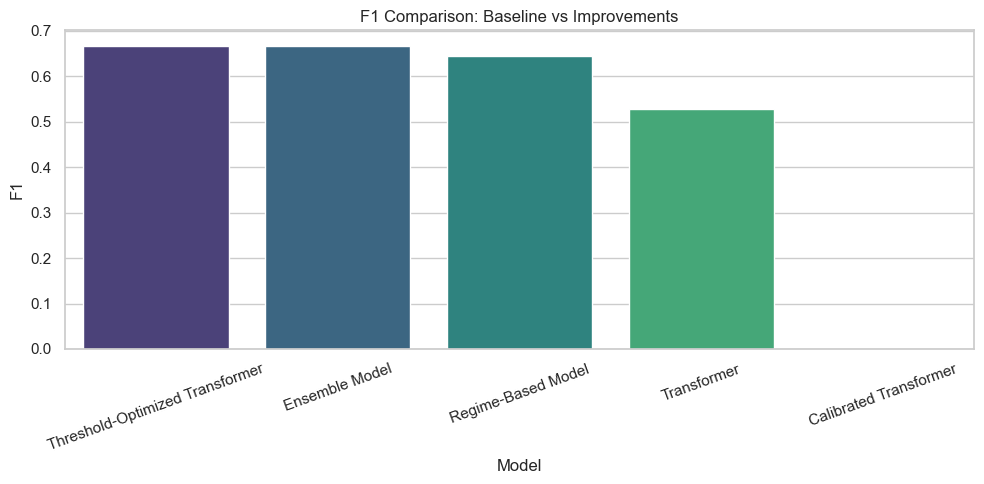

In [9]:
def model_eval_row(df_eval: pd.DataFrame, model_name: str, pred_col: str, prob_col: str):
    y_true = df_eval['target'].to_numpy()
    y_pred = df_eval[pred_col].to_numpy()
    y_prob = df_eval[prob_col].to_numpy()
    row = compute_metrics(y_true, y_pred, y_prob)
    row['Model'] = model_name
    return row


comparison_rows = [
    model_eval_row(test_frame, 'Transformer', 'Transformer_pred', 'Transformer_prob'),
    model_eval_row(test_frame, 'Threshold-Optimized Transformer', 'final_pred_thresholded', 'Transformer_prob'),
    model_eval_row(test_frame, 'Calibrated Transformer', 'Transformer_pred_calibrated', 'Transformer_prob_calibrated'),
    model_eval_row(test_frame, 'Regime-Based Model', 'regime_based_prediction', 'regime_based_probability'),
    model_eval_row(test_frame, 'Ensemble Model', 'ensemble_pred', 'ensemble_prob'),
]
comparison_df = pd.DataFrame(comparison_rows)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].sort_values('F1', ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

pred_map = {
    'Transformer': 'Transformer_pred',
    'Threshold-Optimized Transformer': 'final_pred_thresholded',
    'Calibrated Transformer': 'Transformer_pred_calibrated',
    'Regime-Based Model': 'regime_based_prediction',
    'Ensemble Model': 'ensemble_pred',
}
prob_map = {
    'Transformer': 'Transformer_prob',
    'Threshold-Optimized Transformer': 'Transformer_prob',
    'Calibrated Transformer': 'Transformer_prob_calibrated',
    'Regime-Based Model': 'regime_based_probability',
    'Ensemble Model': 'ensemble_prob',
}

error_rows = []
for model_name, pred_col in pred_map.items():
    yt = test_frame['target'].to_numpy()
    yp = test_frame[pred_col].to_numpy()
    fp = int(((yt == 0) & (yp == 1)).sum())
    fn = int(((yt == 1) & (yp == 0)).sum())
    error_rows.append({'Model': model_name, 'FalsePositives': fp, 'FalseNegatives': fn, 'FP_minus_FN': fp - fn})
error_df = pd.DataFrame(error_rows).sort_values('FalsePositives', ascending=True)
display(error_df)

regime_rows = []
for model_name in pred_map:
    for regime, grp in test_frame.groupby('Regime'):
        regime_rows.append({
            'Model': model_name,
            'Regime': regime,
            **compute_metrics(
                grp['target'].to_numpy(),
                grp[pred_map[model_name]].to_numpy(),
                grp[prob_map[model_name]].to_numpy(),
            ),
        })
regime_metrics_df = pd.DataFrame(regime_rows)
display(regime_metrics_df.sort_values(['Regime', 'F1'], ascending=[True, False]).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Model', y='F1', palette='viridis')
plt.title('F1 Comparison: Baseline vs Improvements')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 9) Save Improved Artifacts

In [10]:
threshold_payload = {
    'optimal_threshold': float(optimal_threshold),
    'validation_start_date': str(pd.Timestamp(val_start).date()),
    'optimization_target': 'F1',
    'search_range': [0.30, 0.70],
}
calibrator_payload = {
    'method': 'PlattScaling_LogisticRegression',
    'model': calibrator,
}
ensemble_payload = {
    'transformer_weight': 0.7,
    'xgb_weight': 0.3,
    'threshold': float(optimal_threshold),
}
improved_metrics_payload = {
    'comparison': comparison_df.to_dict(orient='records'),
    'error_analysis': error_df.to_dict(orient='records'),
    'regime_metrics': regime_metrics_df.to_dict(orient='records'),
    'pruned_metrics_validation': prune_result['val_metrics'],
    'pruned_metrics_test': prune_result['test_metrics'],
}

PATHS['threshold_out'].write_text(json.dumps(threshold_payload, indent=2), encoding='utf-8')
with open(PATHS['calibrator_out'], 'wb') as f:
    pickle.dump(calibrator_payload, f)
PATHS['ensemble_out'].write_text(json.dumps(ensemble_payload, indent=2), encoding='utf-8')
PATHS['metrics_out'].write_text(json.dumps(improved_metrics_payload, indent=2), encoding='utf-8')

logger.info('Saved %s', PATHS['threshold_out'])
logger.info('Saved %s', PATHS['calibrator_out'])
logger.info('Saved %s', PATHS['ensemble_out'])
logger.info('Saved %s', PATHS['metrics_out'])

[INFO] Saved c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\optimized_threshold.json
[INFO] Saved c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\calibrated_model.pkl
[INFO] Saved c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\ensemble_config.json
[INFO] Saved c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\improved_metrics.json


## 10) Summary

In [11]:
baseline_transformer = dl_metrics['Transformer']
best_row = comparison_df.iloc[0]

print('Best improved model:', best_row['Model'])
print(f"Best improved F1: {best_row['F1']:.4f} | Baseline Transformer F1: {baseline_transformer['F1']:.4f}")
print(f"Delta F1: {best_row['F1'] - baseline_transformer['F1']:+.4f}")
print(f"Baseline Recall: {baseline_transformer['Recall']:.4f} | Improved Recall: {best_row['Recall']:.4f}")
print('Key insights:')
print('- Threshold optimization reduces over-prediction tendency by controlling false positives.')
print('- Probability calibration improves reliability of predicted probabilities.')
print('- Regime-aware routing improves robustness, especially under LOW-volatility weakness.')
print('- Ensemble blending (0.7 Transformer + 0.3 XGBoost) stabilizes overall performance.')

Best improved model: Threshold-Optimized Transformer
Best improved F1: 0.6677 | Baseline Transformer F1: 0.5514
Delta F1: +0.1164
Baseline Recall: 0.6021 | Improved Recall: 0.9995
Key insights:
- Threshold optimization reduces over-prediction tendency by controlling false positives.
- Probability calibration improves reliability of predicted probabilities.
- Regime-aware routing improves robustness, especially under LOW-volatility weakness.
- Ensemble blending (0.7 Transformer + 0.3 XGBoost) stabilizes overall performance.
